### Примеры признакового представления в непрерывном пространстве состояний

#### Грубая кодировка (Coarse Coding)

Разместим в $\mathcal S$ набор из $d$ перекрывающихся областей $C_1, C_2, \dots, C_d$. Каждой области сопоставим бинарный признак:
$$
\varphi_i(s) = \begin{cases} 1, & s \in C_i, \\ 0, & s \notin C_i. \end{cases}
$$
Оценка ценности:
$$
V(s; \boldsymbol{w}) = \sum_{i=1}^d w_i \varphi_i(s) = \sum_{i=1}^d w_i \cdot \mathbb{I}(s \in C_i) = \sum_{i: \, s \in C_i} w_i,
$$
Перекрытие областей переносит опыт между соседними состояниями.

#### Плиточное кодирование (Tile Coding)

Пространство состояний покрывается $m$ регулярными сетками, ячейки которых называют плитками. Все $m$ сеток имеют одинаковый шаг, но каждая следующая сетка получается из предыдущей параллельным переносом на вектор смещения $\boldsymbol{\delta}$:
$$
\boldsymbol{\delta} = \frac{w_{\text{tile}}}{m} \begin{bmatrix} 1 & 3 & \ldots & 2n-1\end{bmatrix}^T \in \mathbb R^n,
$$
где $w_{\text{tile}}$ — ширина плитки. Выбор разных нечетных коэффициентов смещения вдоль координатных осей исключает совпадение узлов параллельных сеток. При параллельном переносе внутри каждой сетки точка $s$ попадает ровно в одну ячейку, поэтому вектор признаков $\boldsymbol{\varphi}(s) \in \{0, 1\}^d$ содержит ровно $m$ единиц и $d - m$ нулей. Вычисление ценности сводится к суммированию весов тех плиток, в которые попало текущее состояние:
$$
V(s; \boldsymbol{w}) = \sum_{j=1}^m w_{i_j(s)},
$$
где $i_j(s)$ — индекс активной плитки в $j$-й сетке. Обновление параметров затрагивает только эти $m$ весов:
$$
w_{i_j(s), t+1} = w_{i_j(s), t} + \alpha \delta_t, \quad j = 1, \dots, m.
$$

#### Радиальные базисные функции (Radial Basis Functions, RBF)

Каждый признак $\varphi_i(s)$ задается многомерным гауссовым куполом:
$$
\varphi_i( s) = \exp\left( -\frac{\| s - c_i\|_2^2}{2 \sigma_i^2} \right),
$$
где $\|\cdot\|_2$ — евклидово расстояние, $c_i \in \mathcal{S}$ — центр $i$-го купола, параметр $\sigma_i$ задает радиус зоны влияния.

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import gymnasium as gym
import seaborn as sns

sns.set_theme()
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams.update({'text.usetex': True})
# Поддержку High-DPI (Retina) для Jupyter.
%config InlineBackend.figure_format = 'retina'

# Создаем среду
env = gym.make('MountainCar-v0')
state_low = env.observation_space.low    # [-1.2, -0.07]
state_high = env.observation_space.high  # [ 0.6,  0.07]

# Нормализатор состояния в единичный квадрат [0, 1]^2
def normalize_state(s):
    return (s - state_low) / (state_high - state_low)

# Простая стратегия раскачивания: если скорость отрицательная — газ влево, иначе вправо
def energy_pumping_policy(s):
    position, velocity = s
    return 0 if velocity < 0 else 2

In [2]:
# 1. Грубая кодировка: N случайных перекрывающихся кругов
class CoarseCodingExtractor:
    def __init__(self, num_circles=100, radius=0.15, seed=42):
        np.random.seed(seed)
        self.dim = num_circles
        self.radius = radius
        # Случайные центры кругов в нормализованном пространстве [0, 1]^2
        self.centers = np.random.uniform(0.0, 1.0, size=(num_circles, 2))
        
    def transform(self, s):
        s_norm = normalize_state(s)
        # Евклидово расстояние от точки до всех центров
        dists = np.linalg.norm(self.centers - s_norm, axis=1)
        # Бинарный вектор: 1, если точка внутри круга, иначе 0
        return (dists <= self.radius).astype(np.float64)

# 2. Плиточное кодирование: m сеток со сдвигом (1, 3)
class TileCodingExtractor:
    def __init__(self, num_tilings=8, tiles_per_axis=8):
        self.num_tilings = num_tilings
        self.tiles_per_axis = tiles_per_axis
        # Число плиток в одном разбиении: (tiles_per_axis + 1)^2 из-за сдвига
        self.tiles_per_tiling = (tiles_per_axis + 1) ** 2
        self.dim = self.num_tilings * self.tiles_per_tiling
        
        # Шаг плитки и вектор смещения сеток delta \propto [1, 3]
        self.tile_size = 1.0 / tiles_per_axis
        self.offsets = np.array([
            (i / num_tilings) * np.array([1.0, 3.0]) * (self.tile_size / num_tilings)
            for i in range(num_tilings)
        ])
        
    def transform(self, s):
        s_norm = normalize_state(s)
        features = np.zeros(self.dim)
        
        for j in range(self.num_tilings):
            # Смещенные координаты относительно сетки j
            shifted = s_norm + self.offsets[j]
            x_idx = int(shifted[0] / self.tile_size)
            y_idx = int(shifted[1] / self.tile_size)
            x_idx = np.clip(x_idx, 0, self.tiles_per_axis)
            y_idx = np.clip(y_idx, 0, self.tiles_per_axis)
            
            # Локальный индекс внутри сетки j
            local_idx = x_idx * (self.tiles_per_axis + 1) + y_idx
            # Глобальный индекс в общем векторе признаков
            global_idx = j * self.tiles_per_tiling + local_idx
            features[global_idx] = 1.0
            
        return features

# 3. Радиальные базисные функции: регулярная сетка гауссиан
class RBFExtractor:
    def __init__(self, grid_size=8, sigma=0.1):
        self.dim = grid_size * grid_size
        self.sigma = sigma
        
        # Регулярная сетка центров в [0, 1]^2
        coords = np.linspace(0.0, 1.0, grid_size)
        xx, yy = np.meshgrid(coords, coords)
        self.centers = np.column_stack([xx.ravel(), yy.ravel()])
        
    def transform(self, s):
        s_norm = normalize_state(s)
        # Гауссов купол от каждого центра
        dists_sq = np.sum((self.centers - s_norm) ** 2, axis=1)
        return np.exp(-dists_sq / (2.0 * self.sigma ** 2))

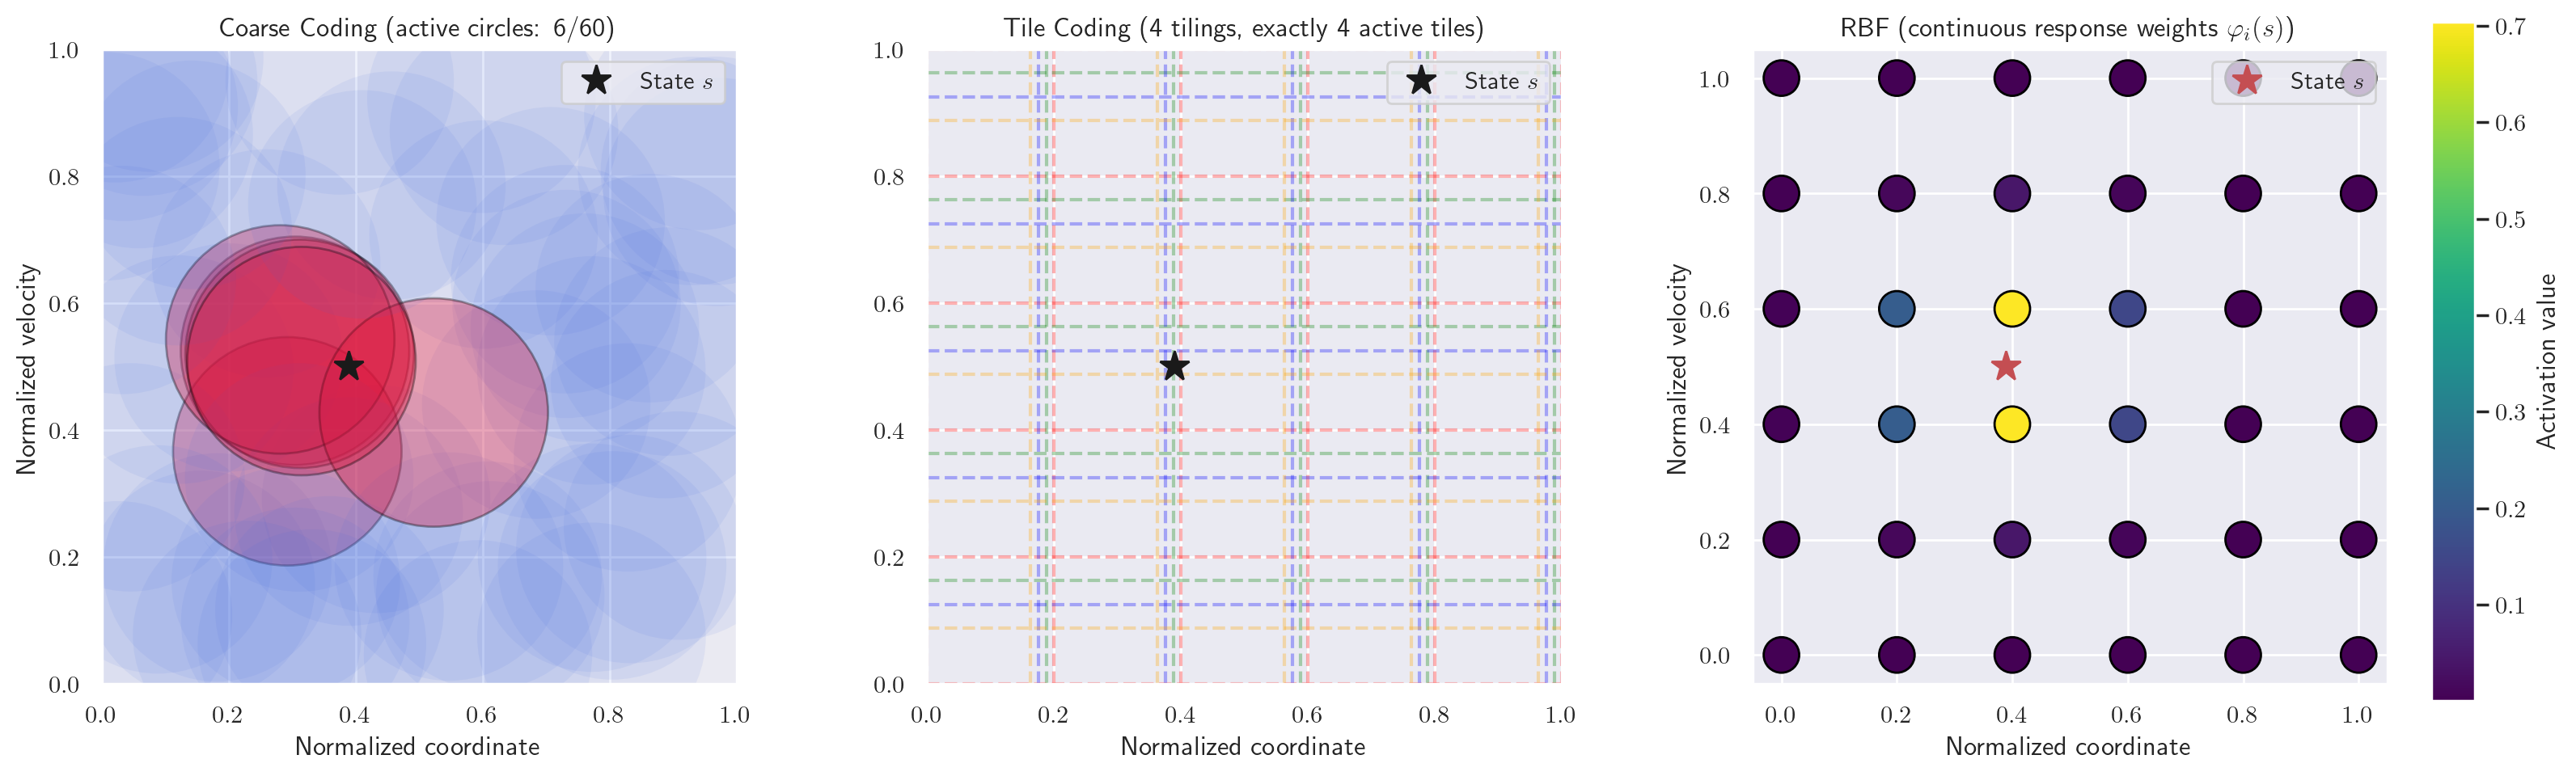

In [3]:
# Фиксированная тестовая точка состояния
test_s = np.array([-0.5, 0.0])
test_norm = normalize_state(test_s)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- 1. Coarse Coding ---
coarse = CoarseCodingExtractor(num_circles=60, radius=0.18)
phi_c = coarse.transform(test_s)
ax = axes[0]
ax.set_title(f"Coarse Coding (active circles: {int(phi_c.sum())}/{coarse.dim})", fontsize=12)
ax.set_aspect('equal')
for i, center in enumerate(coarse.centers):
    is_active = (phi_c[i] == 1.0)
    circle = plt.Circle(center, coarse.radius, 
                        facecolor='crimson' if is_active else 'royalblue', 
                        alpha=0.35 if is_active else 0.08, 
                        edgecolor='black' if is_active else 'none',
                        linewidth=1.0 if is_active else 0)
    ax.add_patch(circle)
ax.plot(test_norm[0], test_norm[1], 'k*', markersize=14, label='State $s$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel('Normalized coordinate'); ax.set_ylabel('Normalized velocity')
ax.legend(loc='upper right')

# --- 2. Tile Coding ---
tile = TileCodingExtractor(num_tilings=4, tiles_per_axis=5)
ax = axes[1]
ax.set_title(f"Tile Coding ({tile.num_tilings} tilings, exactly {tile.num_tilings} active tiles)", fontsize=12)
ax.set_aspect('equal')
colors = ['red', 'green', 'blue', 'orange']
for j in range(tile.num_tilings):
    offset = tile.offsets[j]
    for x in range(tile.tiles_per_axis + 1):
        ax.axvline(x * tile.tile_size - offset[0], color=colors[j], alpha=0.3, linestyle='--')
    for y in range(tile.tiles_per_axis + 1):
        ax.axhline(y * tile.tile_size - offset[1], color=colors[j], alpha=0.3, linestyle='--')
ax.plot(test_norm[0], test_norm[1], 'k*', markersize=14, label='State $s$')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_xlabel('Normalized coordinate')
ax.legend(loc='upper right')

# --- 3. RBF ---
rbf = RBFExtractor(grid_size=6, sigma=0.12)
phi_rbf = rbf.transform(test_s)
ax = axes[2]
ax.set_title(r"RBF (continuous response weights $\varphi_i(s)$)", fontsize=12)
ax.set_aspect('equal')
sc = ax.scatter(rbf.centers[:, 0], rbf.centers[:, 1], c=phi_rbf, cmap='viridis', s=250, edgecolor='black')
ax.plot(test_norm[0], test_norm[1], 'r*', markersize=14, label='State $s$')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05); ax.set_xlabel('Normalized coordinate'); ax.set_ylabel('Normalized velocity')
ax.legend(loc='upper right')

fig.subplots_adjust(right=0.91, wspace=0.3)
cbar_ax = fig.add_axes([0.925, 0.15, 0.015, 0.7])
fig.colorbar(sc, cax=cbar_ax, label='Activation value')

plt.show()

In [4]:
def semi_gradient_td0_prediction(env, pi, feature_extractor, episodes=150, alpha=0.03, gamma=0.99):
    dim = feature_extractor.dim
    w = np.zeros(dim)
    
    for ep in range(episodes):
        state, info = env.reset()
        done = False
        phi_s = feature_extractor.transform(state)
        
        while not done:
            action = pi(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            
            v_current = np.dot(w, phi_s)
            
            if terminated:
                td_error = reward - v_current
            else:
                phi_next = feature_extractor.transform(next_state)
                v_next = np.dot(w, phi_next)
                td_error = reward + gamma * v_next - v_current
                
            w += alpha * td_error * phi_s
            
            if not done:
                state = next_state
                phi_s = phi_next
                
    return w


# 1. Coarse Coding
extractor_coarse = CoarseCodingExtractor(num_circles=120, radius=0.15)

start = time.perf_counter()

w_coarse = semi_gradient_td0_prediction(
    env,
    energy_pumping_policy,
    extractor_coarse,
    episodes=150,
    alpha=0.03
)

time_coarse = time.perf_counter() - start


# 2. Tile Coding
extractor_tile = TileCodingExtractor(num_tilings=8, tiles_per_axis=8)

start = time.perf_counter()

w_tile = semi_gradient_td0_prediction(
    env,
    energy_pumping_policy,
    extractor_tile,
    episodes=150,
    alpha=0.2 / 8
)

time_tile = time.perf_counter() - start


# 3. RBF
extractor_rbf = RBFExtractor(grid_size=8, sigma=0.08)

start = time.perf_counter()

w_rbf = semi_gradient_td0_prediction(
    env,
    energy_pumping_policy,
    extractor_rbf,
    episodes=150,
    alpha=0.05
)

time_rbf = time.perf_counter() - start


print("Обучение аппроксиматоров завершено")
print()
print(f"Coarse Coding: {time_coarse:.3f} s, {extractor_coarse.dim} features")
print(f"Tile Coding:   {time_tile:.3f} s, {extractor_tile.dim} features")
print(f"RBF:           {time_rbf:.3f} s, {extractor_rbf.dim} features")

Обучение аппроксиматоров завершено

Coarse Coding: 0.642 s, 120 features
Tile Coding:   3.110 s, 648 features
RBF:           0.543 s, 64 features


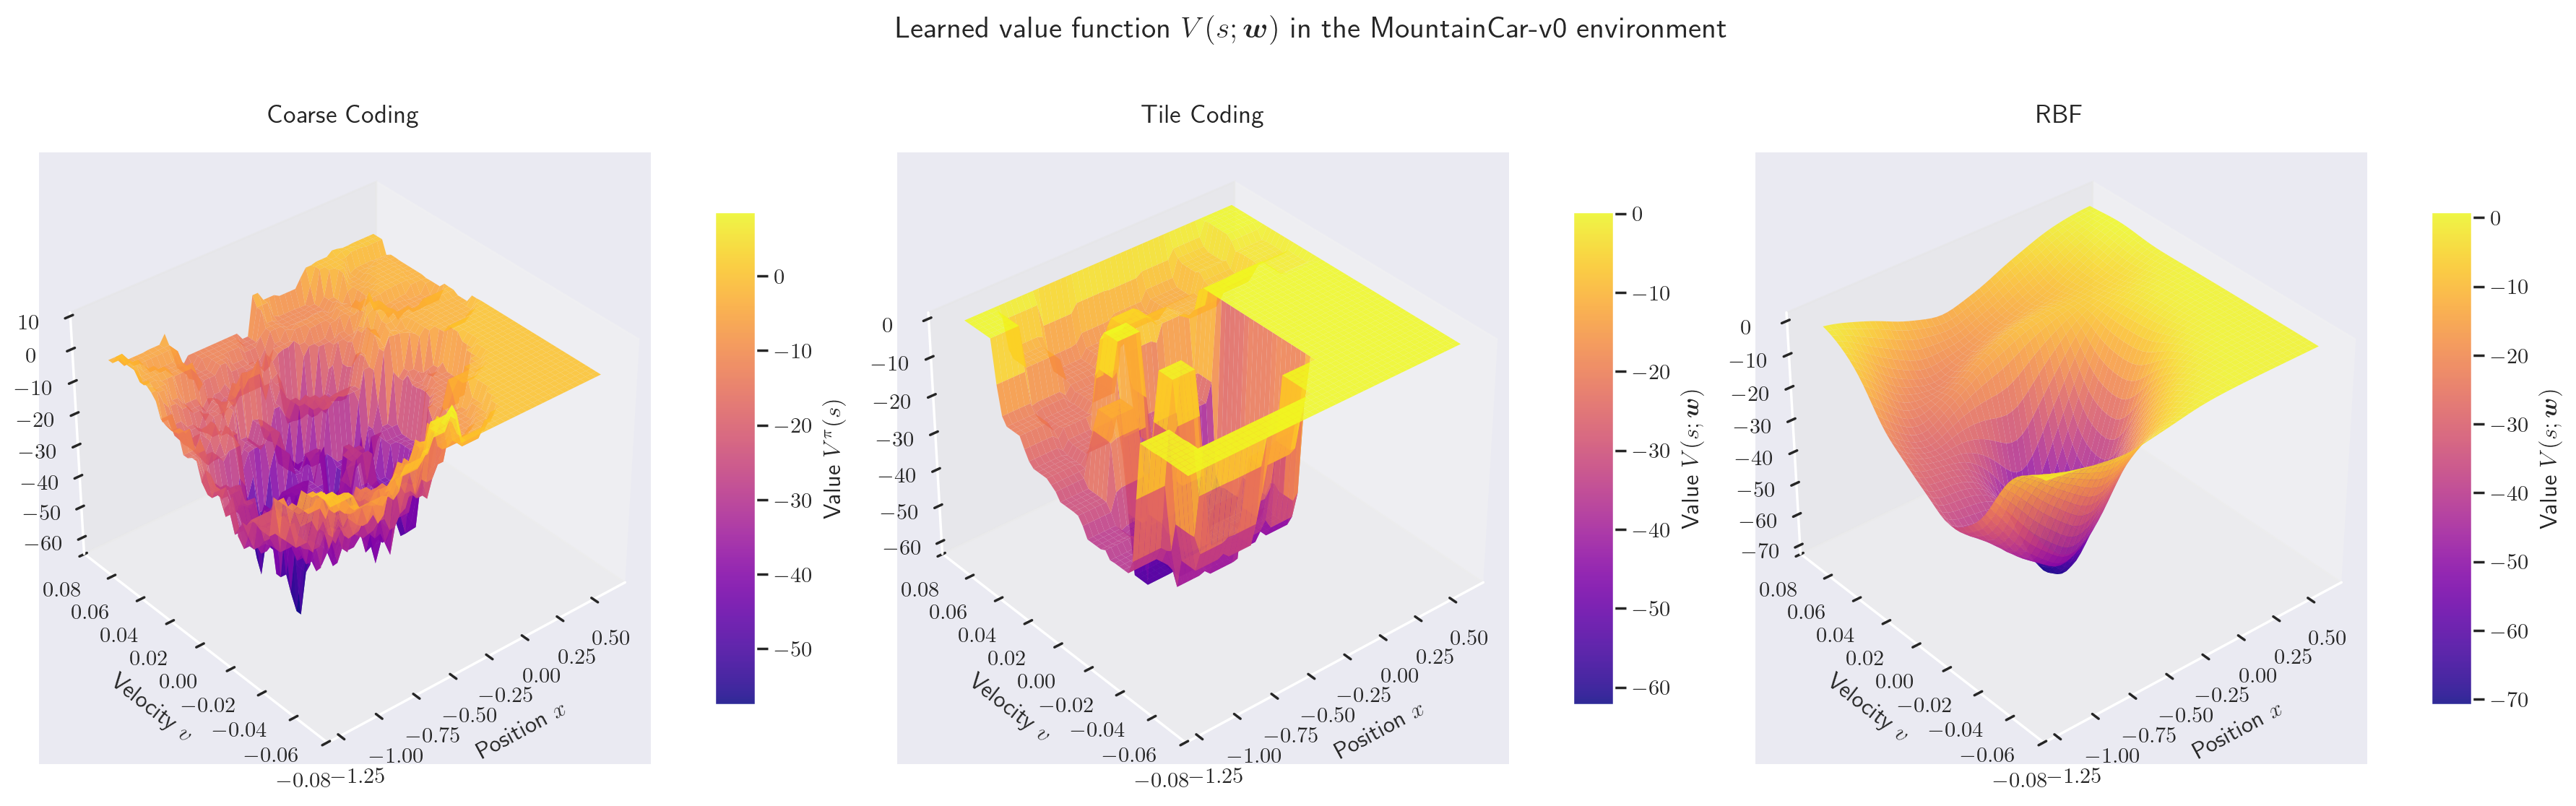

In [5]:
# Сетка точек в пространстве состояний среды MountainCar
pos_grid = np.linspace(state_low[0], state_high[0], 50)
vel_grid = np.linspace(state_low[1], state_high[1], 50)
P, V_vel = np.meshgrid(pos_grid, vel_grid)

V_pred_coarse = np.zeros_like(P)
V_pred_tile = np.zeros_like(P)
V_pred_rbf = np.zeros_like(P)

for i in range(P.shape[0]):
    for j in range(P.shape[1]):
        s = np.array([P[i, j], V_vel[i, j]])
        V_pred_coarse[i, j] = np.dot(w_coarse, extractor_coarse.transform(s))
        V_pred_tile[i, j] = np.dot(w_tile, extractor_tile.transform(s))
        V_pred_rbf[i, j] = np.dot(w_rbf, extractor_rbf.transform(s))

fig = plt.figure(figsize=(18, 6))

models = [
    ("Coarse Coding", V_pred_coarse),
    ("Tile Coding", V_pred_tile),
    ("RBF", V_pred_rbf)
]

for idx, (title, V_vals) in enumerate(models, 1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')
    surf = ax.plot_surface(P, V_vel, V_vals, cmap='plasma', edgecolor='none', alpha=0.85)
    ax.set_title(title, fontsize=13, pad=15)
    ax.set_xlabel('Position $x$', labelpad=5)
    ax.set_ylabel('Velocity $v$', labelpad=5)
    ax.view_init(elev=35, azim=230)
    ax.grid(False)

    cbar = fig.colorbar(surf, ax=ax, shrink=0.65, aspect=12, pad=0.08)
    cbar.set_label(r'Value $V(s; \boldsymbol{w})$' if idx > 1 else r'Value $V^\pi(s)$')

plt.suptitle(
    r"Learned value function $V(s; \boldsymbol{w})$ in the MountainCar-v0 environment",
    fontsize=15,
    y=0.98
)

plt.tight_layout()
plt.show()

#### Контрпример Леона Бэрда (1995)

Рассмотрим MDP с семью состояниями $\{1,\ldots,7\}$ и двумя действиями $a_1$ и $a_2$. Действие $a_1$ детерминированно переводит среду в состояние 7. Действие $a_2$ с равными вероятностями $1/6$ переводит среду в одно из состояний ${1,\ldots,6}$. Все награды равны нулю.

Целевая стратегия $\pi$ всегда выбирает действие $a_1$:
$$
\pi(a_1\mid s)=1.
$$
Поведенческая стратегия $b$ выбирает действия следующим образом:
$$
b(a_2\mid s)=\frac{6}{7},
\quad
b(a_1\mid s)=\frac{1}{7}.
$$
Off-policy: траектории генерируются поведенческой стратегий $b$, а TD-цель соответствует целевой стратегии $\pi$. Для линейной аппроксимации используются восемь параметров $\boldsymbol{w}=(w_1,\ldots,w_8)^T$:
$$
V(1;\boldsymbol{w})=2w_1+w_8, \quad \ldots, \quad V(6;\boldsymbol{w})=2w_6+w_8,
\quad
V(7;\boldsymbol{w})=w_7+2w_8.
$$
Истинная функция ценности целевой стратегии равна нулю: $V^\pi(s)=0$. Следовательно должно быть $\boldsymbol{w}=\mathbf{0}$. Тем не менее semi-gradient TD(0) в этой постановке может расходится.

Контрпример Бэрда доказывает, что нестабильность TD-методов с аппроксимацией — это фундаментальное следствие геометрии проецирования в off-policy условиях, а не недостаток нейросетей или стохастического шума.

In [6]:
# Матрицу признаков Phi размера (7 x 8)
# Строки — состояния 1..7, столбцы — веса w_1..w_8
Phi = np.zeros((7, 8))

# Состояния 1..6: V(s) = 2*w_s + w_8
for s in range(6):
    Phi[s, s] = 2.0
    Phi[s, 7] = 1.0

# Состояние 7: V(7) = w_7 + 2*w_8
Phi[6, 6] = 1.0
Phi[6, 7] = 2.0

# Параметры задачи
gamma = 0.99
alpha = 0.01
steps = 2000

# Инициализация весов
w = np.array([1., 1., 1., 1., 1., 1., 10., 1.])

weight_norms = []
w_history = []

for t in range(steps):
    weight_norms.append(np.linalg.norm(w))
    w_history.append(w.copy())
    
    # Сэмплируем состояние s_t по поведенческой стратегии b(s)
    s = np.random.randint(0, 7)

    # Целевая стратегия детерминированно переходит в состояние 7
    s_target = 6
    
    phi_s = Phi[s]
    phi_target = Phi[s_target]
    
    # Награда r=0
    v_target = np.dot(w, phi_target)
    v_current = np.dot(w, phi_s)
    td_error = 0.0 + gamma * v_target - v_current
    
    # Полуградиентный шаг
    w += alpha * td_error * phi_s

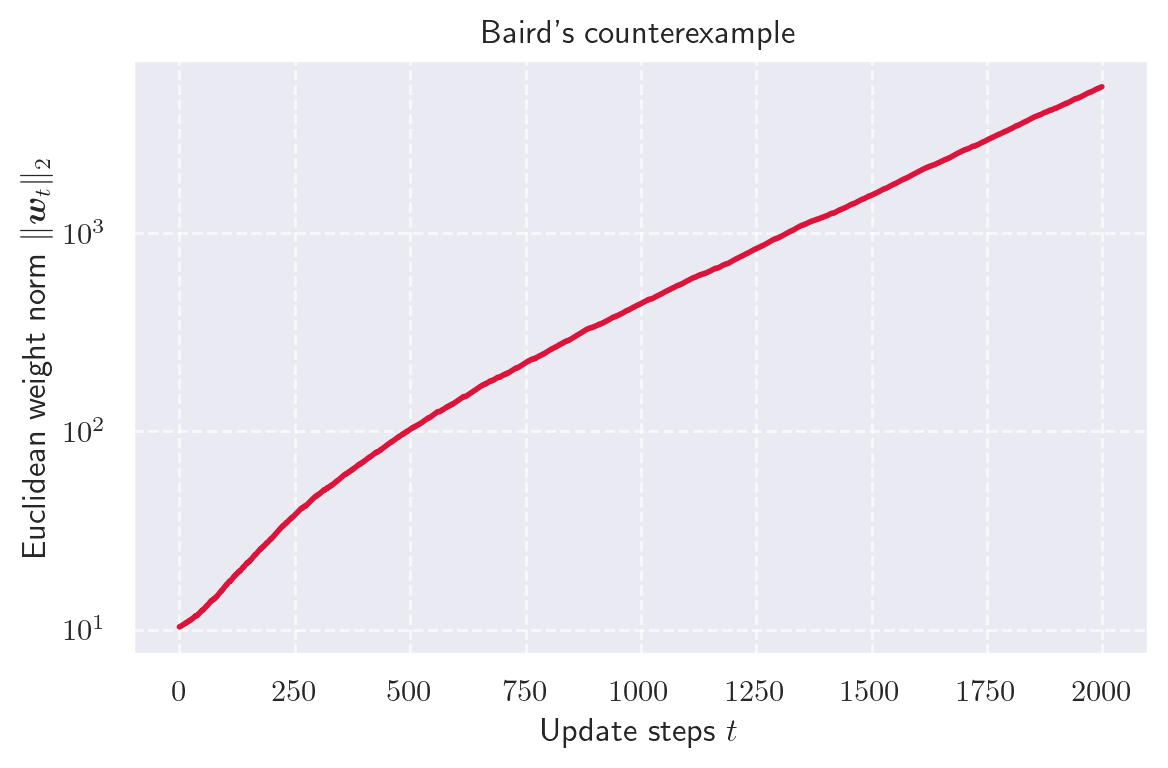

Initial weight norm: 10.34
Final weight norm after 2000 steps: 5474.02


In [7]:
plt.figure(figsize=(6, 4))
plt.plot(weight_norms, color='crimson', linewidth=2)
plt.title("Baird's counterexample")
plt.xlabel(r"Update steps $t$")
plt.ylabel(r"Euclidean weight norm $\|\boldsymbol{w}_t\|_2$")
plt.yscale("log")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print(f"Initial weight norm: {weight_norms[0]:.2f}")
print(f"Final weight norm after {steps} steps: {weight_norms[-1]:.2f}")